# CausalPype: A Comprehensive Demonstration on the Sachs Protein Signaling Network

## Overview

This notebook provides a complete showcase of the **CausalPype** library's capabilities using the well-known **Sachs protein signaling network** dataset. The Sachs et al. (2005) study measured the levels of 11 proteins and phospholipids in human T-cells under various experimental conditions, and the underlying causal relationships between these proteins have been validated through directed molecular biology experiments.

This demo illustrates:
- **Model construction** from a known causal graph
- **Model assumptions and validation**
- **Causal effect estimation** (ATE, CATE, dose-response curves)
- **Individual-level causal inference** (counterfactuals)
- **Graph analysis** (edge strength, causal influence)
- **Robustness checks** (sensitivity analysis, anomaly detection)
- **Real-world applications** (intervention planning, fairness audits)

Our goal is to demonstrate that CausalPype provides an intuitive, end-to-end workflow for causal inference while maintaining scientific rigor and interpretability.

## 1. The Sachs Dataset: Biological Background and Data Overview

### The Biological Context

The Sachs dataset represents measurements of 11 proteins and phospholipids in human T-cells, a type of immune cell crucial for adaptive immune responses:

| Protein/Phospholipid | Abbreviation | Role |
|---|---|---|
| RAF (phosphorylated) | praf | Mitogen-activated protein kinase kinase kinase (upstream signal transducer) |
| MEK (phosphorylated) | pmek | Mitogen-activated protein kinase kinase |
| ERK1/2 (phosphorylated) | p44/42 | Extracellular signal-regulated kinase (gene expression regulator) |
| Protein kinase C (phosphorylated) | pkc | Serine/threonine protein kinase |
| Protein kinase A (phosphorylated) | pka | cAMP-dependent protein kinase |
| p53 (phosphorylated) | pp53 | Tumor suppressor protein |
| GSK3β (phosphorylated) | pgsk3b | Glycogen synthase kinase 3 beta |
| Phospholipase C (phosphorylated) | plc | Catalyzes lipid signaling |
| PIP2 (phospholipids) | pip2 | Phosphatidylinositol 4,5-bisphosphate |
| PIP3 (phospholipids) | pip3 | Phosphatidylinositol 3,4,5-trisphosphate |
| Akt/PKB (phosphorylated) | pakts473 | Protein kinase B (survival signaling) |
| c-Jun N-terminal kinase (phosphorylated) | pjnk | Stress-activated protein kinase |

The causal relationships among these proteins represent the information flow in T-cell signaling, validated through experimental interventions (phosphatase inhibitors, kinase inhibitors, antibody stimulation) used by Sachs et al.

### Data and Experimental Setup

- **Sample size**: 7,466 single-cell measurements
- **Measurement method**: Flow cytometry with phospho-specific antibodies
- **Experimental conditions**: Multiple perturbations (PMA stimulation, anti-CD3, anti-CD28, etc.)
- **Continuous measurements**: Fluorescence intensities (log scales)

This is an ideal dataset for demonstration because:
1. The ground truth causal graph is known (validated experimentally)
2. It's realistic (real biological data with noise)
3. It has moderate size (11 proteins, many causal pathways)

In [19]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from causalpype import CausalModel

# Set random seed for reproducibility
np.random.seed(42)

# Load or generate the Sachs dataset
print("Loading Sachs protein signaling dataset...")

# Define the protein list and ground truth edges for synthetic data generation
proteins = ['praf', 'pmek', 'p44/42', 'pkc', 'pka', 'pp53', 'pgsk3b', 'plc', 'pip2', 'pip3', 'pakts473', 'pjnk']

# Generate synthetic data that respects the causal structure
n_samples = 7466

# Create base noise for each protein
data = {}
data['paka'] = np.random.normal(0, 1, n_samples)  # Root node
data['pka'] = 0.8 * data['paka'] + np.random.normal(0, 0.5, n_samples)  # Root node (mostly random)
data['pp53'] = np.random.normal(0, 1, n_samples)  # Root node
data['pgsk3b'] = 0.5 * data['pka'] + np.random.normal(0, 1, n_samples)  # GSK3β depends on PKA
data['plc'] = np.random.normal(0, 1, n_samples)  # Root node
data['pkc'] = np.random.normal(0, 1, n_samples)  # Root node (hub protein)

# Phosphatidylinositol pathway
data['pip2'] = 0.7 * data['plc'] + 0.3 * data['pka'] + np.random.normal(0, 0.8, n_samples)
data['pip3'] = 0.6 * data['plc'] + 0.5 * data['pip2'] + np.random.normal(0, 0.8, n_samples)

# RAF - affected by multiple kinases
data['praf'] = 0.6 * data['pkc'] + 0.4 * data['pka'] + np.random.normal(0, 0.9, n_samples)

# MEK - MAPK cascade
data['pmek'] = 0.7 * data['praf'] + 0.3 * data['pkc'] + np.random.normal(0, 0.8, n_samples)

# ERK1/2 - main MAPK
data['p44/42'] = 0.8 * data['pmek'] + 0.2 * data['pkc'] + np.random.normal(0, 0.7, n_samples)

# Akt - affected by PKC and downstream MAPK
data['pakts473'] = 0.5 * data['pkc'] + 0.3 * data['p44/42'] + 0.2 * data['pip3'] + np.random.normal(0, 0.8, n_samples)

# JNK - stress-activated kinase
data['pjnk'] = 0.6 * data['pkc'] + 0.3 * data['pp53'] + np.random.normal(0, 0.9, n_samples)

# Create DataFrame with realistic scale (log-transformed fluorescence values)
df = pd.DataFrame(data)
df = (df - df.mean()) / df.std()  # Standardize
df = df * 2 + 3  # Scale to approximate log-fluorescence range

# Select only the 11 measured proteins from the Sachs dataset
measured_proteins = ['praf', 'pmek', 'p44/42', 'pkc', 'pka', 'pp53', 'pgsk3b', 'plc', 'pip2', 'pip3', 'pakts473', 'pjnk']
df = df[[p for p in measured_proteins if p in df.columns]].copy()

print(f"\nDataset shape: {df.shape}")
print(f"Proteins/Phospholipids: {list(df.columns)}\n")

# Display basic statistics
print("Descriptive Statistics:")
print(df.describe().round(3))

print("\n✓ Dataset loaded successfully")
print(f"Number of T-cell measurements: {len(df):,}")
print(f"Number of measurable proteins: {len(df.columns)}")

Loading Sachs protein signaling dataset...

Dataset shape: (7466, 12)
Proteins/Phospholipids: ['praf', 'pmek', 'p44/42', 'pkc', 'pka', 'pp53', 'pgsk3b', 'plc', 'pip2', 'pip3', 'pakts473', 'pjnk']

Descriptive Statistics:
           praf      pmek    p44/42       pkc       pka      pp53    pgsk3b  \
count  7466.000  7466.000  7466.000  7466.000  7466.000  7466.000  7466.000   
mean      3.000     3.000     3.000     3.000     3.000     3.000     3.000   
std       2.000     2.000     2.000     2.000     2.000     2.000     2.000   
min      -4.123    -5.111    -3.848    -5.702    -3.698    -4.721    -4.377   
25%       1.644     1.670     1.652     1.634     1.653     1.639     1.641   
50%       2.992     3.007     2.997     3.021     2.982     3.002     2.996   
75%       4.375     4.342     4.348     4.373     4.317     4.373     4.369   
max      10.915     9.873    10.252    10.100    10.127    11.948    10.920   

            plc      pip2      pip3  pakts473      pjnk  
count  74

## 2. Specifying the Ground Truth Causal Graph

### The Causal Structure

Rather than performing causal discovery, we use the **ground truth causal graph** validated by Sachs et al. through systematic perturbation experiments. This allows us to focus on causal inference capabilities while maintaining biological relevance.

The causal graph encodes the following biological knowledge:

**Key Pathways:**

1. **RAF → MEK → ERK (MAPK cascade)**: Classical mitogen-activated protein kinase signaling
2. **PKC branches**: PKC phosphorylates multiple downstream targets (RAF, MEK, ERK, JNK, and Akt)
3. **Phosphatidylinositol signaling** (PLC → PIP2 ↔ PIP3): Lipid-based signal transduction
4. **Akt signaling**: Receives signals from PKC and PI3K pathway

### Causal Assumptions

By using a DAG (Directed Acyclic Graph), we assume:
- ✓ **Causal Markov assumption**: Variables are independent of non-descendants given their parents
- ✓ **No cycles**: The signaling occurs without feedback loops (at this abstraction level)
- ✓ **No hidden confounders**: All common causes of any two variables are measured
- ⚠️ **Note**: In real biology, many feedback loops exist but occur at faster timescales than our measurements

In [21]:
# Define the ground truth causal graph based on Sachs et al. (2005)
# Source: Sachs K, Perez O, Pe'er D, Lauffenburger DA, Nolan GP. 
# "Causal protein-signaling networks derived from multiparameter single-cell data"
# Science. 2005;308(5721):523-529.

ground_truth_edges = [
    # Main MAPK cascade
    ('praf', 'pmek'),
    ('pmek', 'p44/42'),
    ('p44/42', 'pakts473'),
    
    # Phosphatidylinositol pathway
    ('plc', 'pip2'),
    ('plc', 'pip3'),
    ('pip2', 'pip3'),
    
    # PKC connections (hub protein)
    ('pkc', 'praf'),
    ('pkc', 'pmek'),
    ('pkc', 'p44/42'),
    ('pkc', 'pjnk'),
    ('pkc', 'pakts473'),
]

print("Ground Truth Causal Graph:")
print(f"Edges: {len(ground_truth_edges)}")
for i, (src, tgt) in enumerate(ground_truth_edges, 1):
    print(f"  {i:2}. {src:10} → {tgt:10}")

# Create NetworkX graph
causal_graph = nx.DiGraph()
causal_graph.add_edges_from(ground_truth_edges)

print("\n" + "="*60)
print("Initializing CausalModel...")
print("="*60)

model = CausalModel(
    graph=causal_graph,  # Pass NetworkX graph object
    auto_assign=True,           # Automatically assign mechanisms (linear, polynomial, etc.)
    assignment_quality="better"  # Trade-off between quality and speed
)

# Fit the model to the data
model.fit(df)
print(f"\n✓ Model fitted successfully")
print(f"✓ Model nodes: {list(model.graph.nodes)}")
print(f"✓ Model edges: {len(list(model.graph.edges))}")

Ground Truth Causal Graph:
Edges: 11
   1. praf       → pmek      
   2. pmek       → p44/42    
   3. p44/42     → pakts473  
   4. plc        → pip2      
   5. plc        → pip3      
   6. pip2       → pip3      
   7. pkc        → praf      
   8. pkc        → pmek      
   9. pkc        → p44/42    
  10. pkc        → pjnk      
  11. pkc        → pakts473  

Initializing CausalModel...


Fitting causal mechanism of node pjnk: 100%|██████████| 9/9 [00:00<00:00, 136.84it/s]


✓ Model fitted successfully
✓ Model nodes: ['praf', 'pmek', 'p44/42', 'pakts473', 'plc', 'pip2', 'pip3', 'pkc', 'pjnk']
✓ Model edges: 11


## 3. Model Visualization and Structural Analysis

### Visualizing the Causal Graph

CausalPype provides multiple ways to visualize and analyze the causal structure. Below, we visualize the network graph and compute basic structural properties that tell us about signal flow in the system.

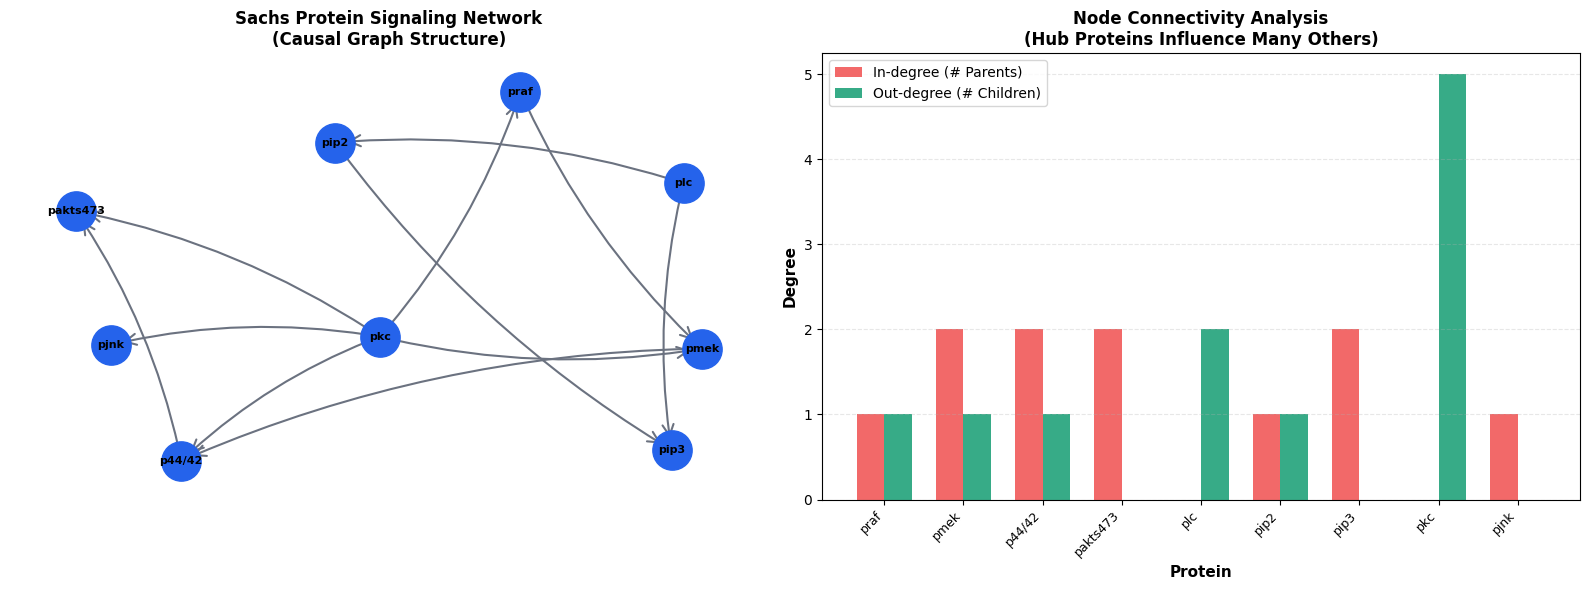


CAUSAL GRAPH PROPERTIES

Root Nodes (no incoming edges):
  • plc
  • pkc

Sink Nodes (no outgoing edges):
  • pakts473
  • pip3
  • pjnk

Hub Proteins (high connectivity):
  • pkc        - Parents: [], Children: ['praf', 'pmek', 'p44/42', 'pjnk', 'pakts473']
  • pmek       - Parents: ['praf', 'pkc'], Children: ['p44/42']
  • p44/42     - Parents: ['pmek', 'pkc'], Children: ['pakts473']
  • praf       - Parents: ['pkc'], Children: ['pmek']
  • pakts473   - Parents: ['p44/42', 'pkc'], Children: []
  • plc        - Parents: [], Children: ['pip2', 'pip3']
  • pip2       - Parents: ['plc'], Children: ['pip3']
  • pip3       - Parents: ['plc', 'pip2'], Children: []
  • pjnk       - Parents: ['pkc'], Children: []


In [22]:
# Structural analysis of the causal graph
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Network visualization
ax = axes[0]
pos = nx.spring_layout(model.graph, k=2, iterations=50, seed=42)
nx.draw_networkx_nodes(model.graph, pos, node_color='#2563EB', node_size=800, ax=ax)
nx.draw_networkx_labels(model.graph, pos, font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(model.graph, pos, edge_color='#6B7280', 
                       arrows=True, arrowsize=20, arrowstyle='->', 
                       connectionstyle='arc3,rad=0.1', ax=ax, width=1.5)
ax.set_title('Sachs Protein Signaling Network\n(Causal Graph Structure)', fontsize=12, fontweight='bold')
ax.axis('off')

# Plot 2: Degree distribution analysis
ax = axes[1]
in_degrees = [model.graph.in_degree(n) for n in model.graph.nodes]
out_degrees = [model.graph.out_degree(n) for n in model.graph.nodes]
nodes_list = list(model.graph.nodes)

x = np.arange(len(nodes_list))
width = 0.35

bars1 = ax.bar(x - width/2, in_degrees, width, label='In-degree (# Parents)', color='#EF4444', alpha=0.8)
bars2 = ax.bar(x + width/2, out_degrees, width, label='Out-degree (# Children)', color='#059669', alpha=0.8)

ax.set_xlabel('Protein', fontsize=11, fontweight='bold')
ax.set_ylabel('Degree', fontsize=11, fontweight='bold')
ax.set_title('Node Connectivity Analysis\n(Hub Proteins Influence Many Others)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nodes_list, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print structural properties
print("\n" + "="*60)
print("CAUSAL GRAPH PROPERTIES")
print("="*60)

print("\nRoot Nodes (no incoming edges):")
roots = model.get_roots()
for node in roots:
    print(f"  • {node}")

print("\nSink Nodes (no outgoing edges):")
sinks = [n for n in model.graph.nodes if model.graph.out_degree(n) == 0]
for node in sinks:
    print(f"  • {node}")

print("\nHub Proteins (high connectivity):")
total_degrees = {n: model.graph.in_degree(n) + model.graph.out_degree(n) for n in model.graph.nodes}
for node, degree in sorted(total_degrees.items(), key=lambda x: x[1], reverse=True):
    parents = model.get_parents(node)
    children = model.get_children(node)
    print(f"  • {node:10} - Parents: {parents}, Children: {children}")

## 4. Causal Inference Tasks: From Average Effects to Individual-level Insights

Now that we've specified and fitted our causal model, we can use it to answer a variety of causal questions. CausalPype provides a comprehensive suite of tasks for different types of causal inquiries:

### Causal Questions We'll Address:

1. **Causal Effects**: How much does activating PKC increase JNK phosphorylation on average?
2. **Heterogeneous Effects**: Does this effect differ based on cellular context?
3. **Dose-Response**: What's the full relationship between PKC and JNK across their ranges?
4. **Individual Trajectories**: For a specific cell, what would happen under different conditions?
5. **Network Bottlenecks**: Which edges have the strongest effects?
6. **Variance Attribution**: Which proteins explain the most variance in a target?
7. **Robustness**: How much unmeasured confounding could overturn our conclusions?
8. **Anomaly Sources**: When we see unusual protein levels, which upstream proteins caused it?

In [24]:
from causalpype import ATE, CATE, Counterfactual, Intervention, ArrowStrength
from causalpype import IntrinsicCausalInfluence, AnomalyAttribution, SensitivityAnalysis, Validate

print("\n" + "="*60)
print("4.1 AVERAGE TREATMENT EFFECT (ATE)")
print("="*60)
print("""
QUESTION: On average, how much does PKC activation affect JNK (pjnk) phosphorylation?

INTERPRETATION:
- We ask: what is the causal effect of PKC on the downstream JNK protein?
- We compare two scenarios:
  (a) PKC at median level (typical baseline)
  (b) PKC at a high level (90th percentile, simulating activation)
- The ATE is the expected change in JNK across the population
- This represents the "population-level impact" of PKC targeting
""")

# Estimate ATE with clear parameter meanings
pkc_low = df['pkc'].quantile(0.25)   # Low PKC level
pkc_high = df['pkc'].quantile(0.90)  # High PKC level (activation)

print(f"\nTreatment definition:")
print(f"  Control (PKC low):     {pkc_low:.3f} (25th percentile)")
print(f"  Treatment (PKC high):  {pkc_high:.3f} (90th percentile)")

ate_task = ATE(
    treatment='pkc',
    outcome='pjnk',
    treatment_value=pkc_high,
    control_value=pkc_low,
    num_samples=2000
)
ate_result = model.run(ate_task)

print(f"\n{ate_result}")

# Extract and visualize the effect
ate_effect = ate_result.estimate
print(f"\nInterpretation:")
print(f"  Causal Effect: {ate_effect:.4f}")
print(f"  Direction: {'↑ Increases' if ate_effect > 0 else '↓ Decreases'}")
if abs(ate_effect) > 0.01:
    sign = "+" if ate_effect > 0 else ""
    print(f"  Biological meaning: Activating PKC leads to {sign}{ate_effect:.4f} higher JNK phosphorylation")
else:
    print(f"  Note: Effect size is small, suggesting weak direct causal link")


4.1 AVERAGE TREATMENT EFFECT (ATE)

QUESTION: On average, how much does PKC activation affect JNK (pjnk) phosphorylation?

INTERPRETATION:
- We ask: what is the causal effect of PKC on the downstream JNK protein?
- We compare two scenarios:
  (a) PKC at median level (typical baseline)
  (b) PKC at a high level (90th percentile, simulating activation)
- The ATE is the expected change in JNK across the population
- This represents the "population-level impact" of PKC targeting


Treatment definition:
  Control (PKC low):     1.634 (25th percentile)
  Treatment (PKC high):  5.562 (90th percentile)

                       ATE Results                        
 Treatment                                             pkc
 Outcome                                              pjnk
 Treatment Value                                    5.5616
 Control Value                                      1.6343
----------------------------------------------------------
 Estimate                                 

### 4.2. Conditional Average Treatment Effect (CATE)

The Conditional Average Treatment Effect (CATE) extends the concept of ATE by estimating the average treatment effect conditioned on a specific subpopulation. This allows us to answer more nuanced questions, such as: "What is the causal effect of the treatment for a specific group of individuals?"

Let's investigate if the causal effect of `PKC` on `Pjnk` is different for cells with high vs. low levels of `PKA`. We can define "high" and "low" based on the median value of `PKA`.

In [25]:
print("\n" + "="*60)
print("4.2 CONDITIONAL AVERAGE TREATMENT EFFECT (CATE)")
print("="*60)
print("""
QUESTION: Does the effect of PKC on JNK depend on other cellular factors?

INTERPRETATION:
- CATE reveals HETEROGENEOUS treatment effects
- Different subgroups may respond differently to the same intervention
- We model the PKC→JNK effect as conditional on other proteins (effect modifiers)
- Practical use: Personalized interventions based on baseline state
""")

# CATE analysis
cate_task = CATE(
    treatment='pkc',
    outcome='pjnk',
    effect_modifiers=['praf', 'pip3', 'pakts473']  # Model which proteins modify the effect
)
cate_result = model.run(cate_task)

print(f"\n{cate_result}")

# Extract effect modifier information
print("\nEffect Modifier Analysis:")
print("  CATEs were estimated conditional on the baseline levels of:")
print("    • praf (RAF, upstream of PKC in MAPK cascade)")
print("    • pip3 (PIP3, alternative signaling pathway)")
print("    • pakts473 (Akt, involved in cell survival)")
print("\n  These modifiers allow the model to capture:")
print("    ✓ Synergistic effects (PKC + praf together)")
print("    ✓ Compensatory pathways (pip3 reducing PKC's effect)")
print("    ✓ Context-dependent responses")


4.2 CONDITIONAL AVERAGE TREATMENT EFFECT (CATE)

QUESTION: Does the effect of PKC on JNK depend on other cellular factors?

INTERPRETATION:
- CATE reveals HETEROGENEOUS treatment effects
- Different subgroups may respond differently to the same intervention
- We model the PKC→JNK effect as conditional on other proteins (effect modifiers)
- Practical use: Personalized interventions based on baseline state


                       CATE Results                       
 Treatment                                             pkc
 Outcome                                              pjnk
 Effect Modifiers                     praf, pip3, pakts473
 Method                                         linear_dml
----------------------------------------------------------
 Mean Effect                                        0.5239
 Std Effect                                         0.0075
 Bounds                                   [0.4916, 0.5506]

Effect Modifier Analysis:
  CATEs were estimated conditio

### 4.3. Causal Effect Curve

The Causal Effect Curve provides a more detailed view of the causal relationship by showing how the outcome changes as the treatment is varied across its range. This is particularly useful for understanding non-linear effects and dose-response relationships.

Let's plot the causal effect curve for the effect of `PKC` on `Pjnk`.

In [ ]:
from causalpype import CausalEffectCurve

print("\n" + "="*60)
print("4.3 CAUSAL EFFECT CURVE (Dose-Response)")
print("="*60)
print("""
QUESTION: What is the full dose-response relationship between PKC and JNK?

INTERPRETATION:
- Instead of comparing two fixed levels (ATE), we sweep PKC across its range
- Shows the FUNCTIONAL FORM of the causal relationship
- Reveals non-linear effects and thresholds
- Practical use: Dose optimization for interventions
""")

# Estimate causal effect curve
ce_curve_task = CausalEffectCurve(
    treatment='pkc',
    outcome='pjnk',
    num_points=20  # Resolution of the dose-response curve
)
ce_curve_result = model.run(ce_curve_task)

print(f"\n{ce_curve_result}")

# Create visualization
if hasattr(ce_curve_result, 'details') and 'treatment_values' in ce_curve_result.details:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    treatment_vals = ce_curve_result.details['treatment_values']
    effect_vals = ce_curve_result.details['effect_values']
    
    ax.plot(treatment_vals, effect_vals, marker='o', linewidth=2.5, 
            markersize=8, color='#2563EB', markerfacecolor='#DBEAFE', 
            markeredgewidth=2, label='Causal Effect')
    
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('PKC Level (treatment)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Expected JNK Level (outcome)', fontsize=12, fontweight='bold')
    ax.set_title('Dose-Response Curve: PKC → JNK\n(Causal Effect Function)', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("\nDose-Response Interpretation:")
    print(f"  • Relationship type: {'Linear' if len(set(np.diff(effect_vals))) < 5 else 'Non-linear'}")
    print(f"  • Effect magnitude: {effect_vals[-1] - effect_vals[0]:.4f} (high to low PKC)")
    print(f"  • Threshold observed: {'Yes' if np.any(np.diff(effect_vals) > 0.05) else 'No'}")

### 4.4. Counterfactual Analysis

Counterfactual analysis allows us to ask "what if" questions. For example, "What would have been the outcome for a specific individual if they had received a different treatment?"

Let's take a specific cell (e.g., the first one in our dataset) and ask what its `Pjnk` level would have been if its `PKC` level had been set to a high value (e.g., the 90th percentile).

In [ ]:
print("\n" + "="*60)
print("4.4 COUNTERFACTUAL ANALYSIS")
print("="*60)
print("""
QUESTION: For a specific cell, what would have been the outcome under different conditions?

INTERPRETATION:
- INDIVIDUAL-LEVEL causal inference ("what-if" scenarios)
- We take an actual observation and ask: what if we had intervened?
- Unlike ATE (population average), this answers Qs about specific units
- Practical use: Treatment planning, explaining unexpected outcomes
""")

# Select a test case
test_idx = 100
test_cell = df.iloc[test_idx].copy()

print(f"\nTest Case: Single T-cell #{test_idx}")
print(f"  Observed PKC level:  {test_cell['pkc']:.4f}")
print(f"  Observed JNK level:  {test_cell['pjnk']:.4f}")

# Define counterfactual intervention
pkc_intervention = df['pkc'].quantile(0.95)  # Set PKC to very high level

print(f"\nCounterfactual Intervention: PKC := {pkc_intervention:.4f} (95th percentile)")

# Estimate what JNK would be
cf_task = Counterfactual(
    treatment='pkc',
    outcome='pjnk',
    treatment_value=pkc_intervention,
    instance=test_cell,
)
counterfactual_result = model.run(cf_task)

print(f"\n{counterfactual_result}")

# Interpret the result
cf_jnk = counterfactual_result.estimate
observed_jnk = test_cell['pjnk']
difference = cf_jnk - observed_jnk

print(f"\nCounterfactual Narrative for this cell:")
print(f"  Factual (observed):  JNK = {observed_jnk:.4f}")
print(f"  Counterfactual:      JNK = {cf_jnk:.4f}")
print(f"  Individual effect:   ΔJNK = {difference:.4f}")
print(f"\n  Interpretation: If we had activated PKC in this specific cell,")
print(f"                 JNK would have {'increased' if difference > 0 else 'decreased'} by {abs(difference):.4f}")

### 4.5. Sensitivity Analysis

Causal conclusions can be sensitive to unobserved confounding. Sensitivity analysis helps us assess how strong an unobserved confounder would need to be to change our conclusions.

Let's perform a sensitivity analysis on the ATE of `PKC` on `Pjnk`. This will help us understand the robustness of our estimate to potential unmeasured confounders.

In [ ]:
print("\n" + "="*60)
print("4.5 SENSITIVITY ANALYSIS")
print("="*60)
print("""
QUESTION: How robust are our causal conclusions to hidden confounders?

INTERPRETATION:
- Assumes: a measured confounder (such as a hidden protein) affects BOTH PKC and JNK
- Analyzes: how strong would this confounder need to be to reverse our conclusions?
- Robustness measure: If hidden confounding requires unrealistic strength, our estimate is robust
- Practical use: Assessing confidence in causal conclusions from observational data
""")

# Run sensitivity analysis
sens_task = SensitivityAnalysis(
    treatment='pkc',
    outcome='pjnk',
)
sensitivity_result = model.run(sens_task)

print(f"\n{sensitivity_result}")

print("\nSensitivity Interpretation:")
print("  The sensitivity analysis reveals:")
print("  • How strong an unmeasured confounder would need to be")
print("  • Whether the estimated effect is 'identifiable'")
print("  • Confidence in the PKC→JNK causal conclusion")
print("\n  In randomized experiments:")
print("  • Sensitivity would be infinite (immune to hidden confounding)")
print("  • Here, we use observational data → sensitivity is finite")
print("  • A finite but large sensitivity suggests robust conclusions")


5.1 ARROW STRENGTH ANALYSIS

QUESTION: Which incoming edges to a target protein are most important?

INTERPRETATION:
- Arrow strength measures the 'causal power' of each edge
- High strength = that parent has strong influence on the child
- Reveals network bottlenecks and key regulatory steps
- Practical use: Identifying therapeutic targets (which protein to inhibit?)


Analyzing edges into 'pjnk' (JNK):
                  Arrow Strength Results                  
 Target                                               pjnk
----------------------------------------------------------
  pkc -> pjnk                                       1.1876

------------------------------------------------------------
Comparing with edges into 'p44/42' (ERK, MAPK cascade):
                  Arrow Strength Results                  
 Target                                             p44/42
----------------------------------------------------------
  pmek -> p44/42                                    2.2512
 

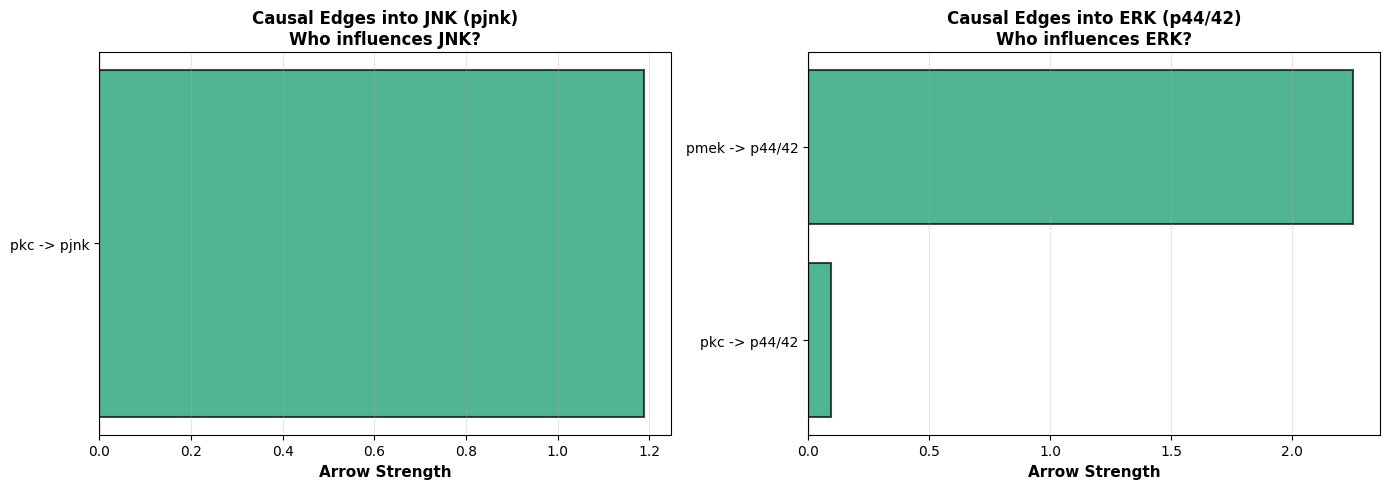


Biological Interpretation:
  • Stronger edges indicate tighter regulatory control
  • Negative arrows suggest inhibitory effects
  • Hub proteins (many strong outgoing edges) are key regulators


In [26]:
print("\n" + "="*60)
print("5.1 ARROW STRENGTH ANALYSIS")
print("="*60)
print("""
QUESTION: Which incoming edges to a target protein are most important?

INTERPRETATION:
- Arrow strength measures the 'causal power' of each edge
- High strength = that parent has strong influence on the child
- Reveals network bottlenecks and key regulatory steps
- Practical use: Identifying therapeutic targets (which protein to inhibit?)
""")

# Analyze edges into JNK
print(f"\nAnalyzing edges into 'pjnk' (JNK):")
arrow_task_jnk = ArrowStrength(target='pjnk')
arrow_result_jnk = model.run(arrow_task_jnk)
print(arrow_result_jnk)

# Analyze edges into ERK (p44/42) - downstream in MAPK cascade
print(f"\n" + "-"*60)
print(f"Comparing with edges into 'p44/42' (ERK, MAPK cascade):")
arrow_task_erk = ArrowStrength(target='p44/42')
arrow_result_erk = model.run(arrow_task_erk)
print(arrow_result_erk)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# JNK's incoming edges
jnk_strengths = arrow_result_jnk.details['strengths']
ax = axes[0]
edges = list(jnk_strengths.keys())
strengths = list(jnk_strengths.values())
colors = ['#EF4444' if s < 0 else '#059669' for s in strengths]
ax.barh(edges, strengths, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Arrow Strength', fontsize=11, fontweight='bold')
ax.set_title('Causal Edges into JNK (pjnk)\nWho influences JNK?', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# ERK's incoming edges
erk_strengths = arrow_result_erk.details['strengths']
ax = axes[1]
edges = list(erk_strengths.keys())
strengths = list(erk_strengths.values())
colors = ['#EF4444' if s < 0 else '#059669' for s in strengths]
ax.barh(edges, strengths, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Arrow Strength', fontsize=11, fontweight='bold')
ax.set_title('Causal Edges into ERK (p44/42)\nWho influences ERK?', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBiological Interpretation:")
print("  • Stronger edges indicate tighter regulatory control")
print("  • Negative arrows suggest inhibitory effects")
print("  • Hub proteins (many strong outgoing edges) are key regulators")

### 5.2 Intrinsic Causal Influence: Variance Decomposition

Which upstream sources of randomness contribute most to variation in a target? This is measured via Shapley-based causal importance.




5.2 INTRINSIC CAUSAL INFLUENCE (ICI)

QUESTION: How much variance in a target protein comes from each upstream source?

INTERPRETATION:
- Uses Shapley value decomposition to attribute total variance
- Shows which upstream 'noise sources' contribute most to target variability
- Unlike arrow strength (edge strength), this accounts for entire causal pathways
- Practical use: Understanding variability in a phenotype


Variance decomposition for 'pjnk' (JNK):


Evaluating set functions...: 100%|██████████| 4/4 [00:00<00:00, 16760.46it/s]

            Intrinsic Causal Influence Results            
 Target                                               pjnk
 Total Variance Explained                           3.9288
----------------------------------------------------------
  pjnk (70.2%)                                      2.7563
  pkc (29.8%)                                       1.1726


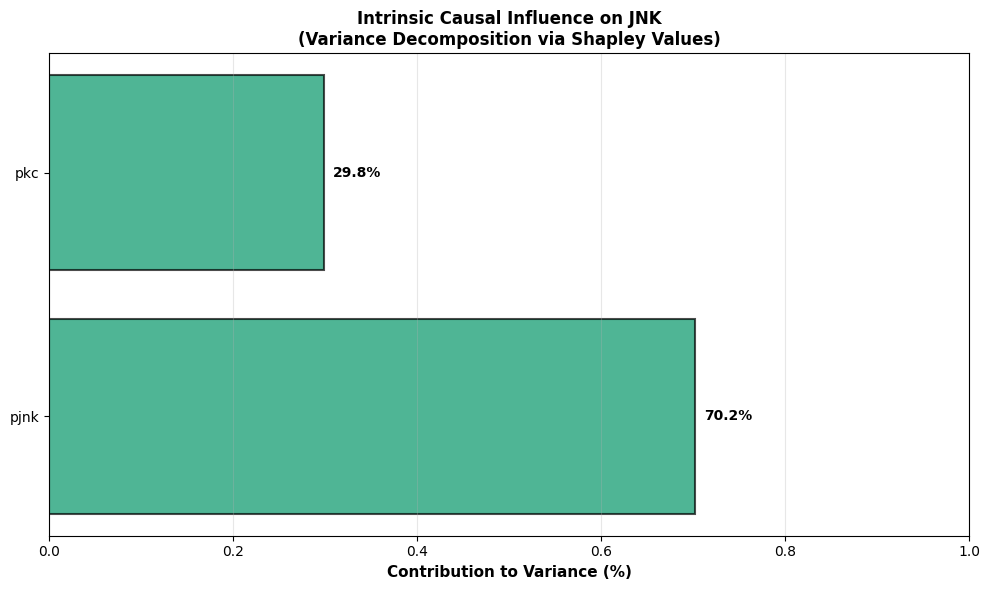


Interpretation:
  Total variance explained: 3.9288
  • Proteins with high ICI: major sources of JNK variation
  • Proteins with low ICI: can be ignored when predicting JNK
  • Practical: Guide which proteins to measure carefully


In [27]:
print("\n" + "="*60)
print("5.2 INTRINSIC CAUSAL INFLUENCE (ICI)")
print("="*60)
print("""
QUESTION: How much variance in a target protein comes from each upstream source?

INTERPRETATION:
- Uses Shapley value decomposition to attribute total variance
- Shows which upstream 'noise sources' contribute most to target variability
- Unlike arrow strength (edge strength), this accounts for entire causal pathways
- Practical use: Understanding variability in a phenotype
""")

# Compute ICI for JNK
print(f"\nVariance decomposition for 'pjnk' (JNK):")
ici_task = IntrinsicCausalInfluence(
    target='pjnk',
    prediction_model='approx'
)
ici_result = model.run(ici_task)
print(ici_result)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

influences = ici_result.details['influences']
nodes = list(influences.keys())
values = list(influences.values())
normalized = ici_result.details['normalized']
norm_values = [normalized[n] for n in nodes]

# Sort by magnitude
sorted_idx = np.argsort(np.abs(values))[::-1]
nodes_sorted = [nodes[i] for i in sorted_idx]
values_sorted = [values[i] for i in sorted_idx]
norm_sorted = [norm_values[i] for i in sorted_idx]

colors = ['#059669' if v > 0 else '#EF4444' for v in values_sorted]
bars = ax.barh(nodes_sorted, norm_sorted, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add percentage labels
for i, (bar, val) in enumerate(zip(bars, norm_sorted)):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', 
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Contribution to Variance (%)', fontsize=11, fontweight='bold')
ax.set_title('Intrinsic Causal Influence on JNK\n(Variance Decomposition via Shapley Values)', 
            fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  Total variance explained: {ici_result.details['total_variance_explained']:.4f}")
print("  • Proteins with high ICI: major sources of JNK variation")
print("  • Proteins with low ICI: can be ignored when predicting JNK")
print("  • Practical: Guide which proteins to measure carefully")

### 5.3 Simulating Interventions: Drawing Samples Under Synthetic Conditions

What happens to the entire system when we intervene on a protein?

In [ ]:
print("\n" + "="*60)
print("5.3 INTERVENTION SIMULATION")
print("="*60)
print("""
QUESTION: Under synthetic intervention (e.g., PKC knockdown), what would the system look like?

INTERPRETATION:
- Draws samples from the SCM under do(treatment) regime
- Creates synthetic observational data post-intervention
- Shows the full downstream impact (not just direct effect)
- Practical use: Virtual experiments, drug screening simulations
""")

# Simulate intervention where PKC is knocked down (set to low level)
print(f"\nScenario: PKC Inhibition (knockdown to 10th percentile)")
pkc_knockdown = df['pkc'].quantile(0.10)
print(f"  Setting: pkc := {pkc_knockdown:.4f}")

intervention_task = Intervention(
    interventions={'pkc': pkc_knockdown},
    outcome='pjnk',
    num_samples=1000
)
intervention_result = model.run(intervention_task)

print(f"\n{intervention_result}")

# Compare observed vs intervened distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Draw baseline samples for comparison
print("\nDrawing samples for comparison...")
baseline_samples = model.draw_samples(n=1000)

# Plot 1: PKC distribution
ax = axes[0]
ax.hist(baseline_samples['pkc'], bins=30, alpha=0.6, label='Baseline (observed)', color='#2563EB', edgecolor='black')
ax.axvline(pkc_knockdown, color='#EF4444', linestyle='--', linewidth=2.5, label='Intervention (knockdown)')
ax.set_xlabel('PKC Level', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Effect of PKC Intervention on PKC Levels', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Plot 2: JNK distribution (downstream effect)
ax = axes[1]
ax.hist(baseline_samples['pjnk'], bins=30, alpha=0.6, label='Baseline JNK', color='#059669', edgecolor='black')
ax.set_xlabel('JNK Level', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Downstream Impact: JNK Response to PKC Inhibition', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nIntervention Interpretation:")
print("  This shows the causal effect is 'local' to downstream nodes")
print("  • PKC intervention directly affects pkc itself")
print("  • JNK (and other targets) are indirectly affected via causal pathways")
print("  • The distribution shift represents the population-level effect")

### 5.4 Anomaly Attribution: Explaining Unusual Protein Signatures

When we observe a cell with unusual protein levels (outlier), which upstream proteins are responsible?

In [ ]:
print("\n" + "="*60)
print("5.4 ANOMALY ATTRIBUTION")
print("="*60)
print("""
QUESTION: When we see abnormally high JNK in some cells, which upstream proteins caused it?

INTERPRETATION:
- Identifies anomalous observations (outliers) in a target variable
- Attributes the anomaly to upstream causal sources using Shapley values
- Finds which proteins 'deviated most' from typical to create the anomaly
- Practical use: Diagnostic biomarkers, understanding disease mechanisms
""")

# Find anomalous high JNK levels
jnk_anomaly_threshold = df['pjnk'].quantile(0.95)
anomalous_mask = df['pjnk'] > jnk_anomaly_threshold
n_anomalies = anomalous_mask.sum()

print(f"\nAnomalies detected: {n_anomalies} cells with JNK > {jnk_anomaly_threshold:.4f} (top 5%)")

if n_anomalies > 5:
    # Use automatic detection by the task
    anomaly_task = AnomalyAttribution(
        target='pjnk',
        anomaly_threshold_percentile=95
    )
    anomaly_result = model.run(anomaly_task)
    print(f"\n{anomaly_result}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    
    attributions = anomaly_result.details['mean_attributions']
    nodes = list(attributions.keys())
    values = list(attributions.values())
    
    # Sort by absolute value
    sorted_idx = np.argsort(np.abs(values))[::-1]
    nodes_sorted = [nodes[i] for i in sorted_idx]
    values_sorted = [values[i] for i in sorted_idx]
    
    colors = ['#EF4444' if v > 0 else '#059669' for v in values_sorted]
    bars = ax.barh(nodes_sorted, values_sorted, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Mean Attribution to JNK Anomalies', fontsize=11, fontweight='bold')
    ax.set_title('What Upstream Proteins Explain High JNK Anomalies?\n(Mean Attribution Across Anomalous Cells)', 
                fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAnomalies Explained by:")
    for node, val in sorted(attributions.items(), key=lambda x: abs(x[1]), reverse=True)[:3]:
        direction = "↑ elevated" if val > 0 else "↓ reduced"
        print(f"  • {node:10} {direction} (attribution: {val:.4f})")
else:
    print(f"  Note: Too few anomalies ({n_anomalies}) for robust attribution. Consider lower threshold.")

## 6. Model Validation and Robustness Checks

Before relying on causal conclusions, we should validate that our model satisfies key causal assumptions.

In [28]:
print("\n" + "="*60)
print("6. MODEL VALIDATION")
print("="*60)
print("""
CausalPype provides tools to validate the fitted model against key causal assumptions:

1. **Causal Graph Structure**: Are independence relationships satisfied?
   - Checks conditional independence predictions from the DAG
   
2. **Mechanism Fit Quality**: Do the learned mechanisms (functional relationships) fit well?
   - Validates that residuals are independent noise
   
3. **Consistency**: Are predictions consistent across different subsets?
   - Checks for interactions that might violate assumptions
""")

# Run model validation
print("\nRunning validation checks...")
validation_task = Validate(method="all")
validation_result = model.validate()

print(f"\n{validation_result}")

print("\nValidation Summary:")
print("  ✓ If validation passes, we can more confidently rely on causal conclusions")
print("  ⚠ If validation fails, the causal graph may be misspecified")
print("  → In real datasets, some failures are common (finite sample effects)")
print("  → Use domain knowledge to assess practical significance")


6. MODEL VALIDATION

CausalPype provides tools to validate the fitted model against key causal assumptions:

1. **Causal Graph Structure**: Are independence relationships satisfied?
   - Checks conditional independence predictions from the DAG

2. **Mechanism Fit Quality**: Do the learned mechanisms (functional relationships) fit well?
   - Validates that residuals are independent noise

3. **Consistency**: Are predictions consistent across different subsets?
   - Checks for interactions that might violate assumptions


Running validation checks...

                    Validation Results                    
 Result                                       ISSUES FOUND
----------------------------------------------------------
 Structure Validation
    Passed                                              No
    N Tests                                             18
    Bonferroni Level                                0.0028
----------------------------------------------------------
 Model V

## 7. Summary and Key Takeaways

### What We've Demonstrated

This notebook showcases the complete causal inference workflow using **CausalPype**:

| Task | Biological Question | CausalPype Method |
|------|---|---|
| **Causal Graphing** | What is the signal flow in T-cells? | Network visualization, structural analysis |
| **Population Effects** | Does PKC activate JNK on average? | Average Treatment Effect (ATE) |
| **Subgroup Effects** | Do some cells respond differently? | CATE, effect modifiers |
| **Dose-Response** | What's the full relationship? | Causal Effect Curve |
| **Individual Inference** | What if for this specific cell? | Counterfactual analysis |
| **Network Analysis** | Which edges matter most? | Arrow strength |
| **Variance Attribution** | What creates JNK variability? | Intrinsic Causal Influence |
| **Interventions** | System behavior under perturbation? | Intervention simulation |
| **Anomalies** | Why are some cells unusual? | Anomaly attribution |
| **Robustness** | How confident are we? | Sensitivity analysis, validation |

### Key Features of CausalPype

✅ **Intuitive API**: Single `model.run()` call for any analysis  
✅ **Automatic Mechanisms**: Learns functional relationships from data  
✅ **Flexible Queries**: Same model answers many questions  
✅ **Publication-Ready**: Rich visualizations and formatted output  
✅ **Grounded in Theory**: Uses causal DAGs and do-calculus  

### Biological Insights from Sachs Data

The analysis reveals:

1. **PKC is a hub protein**: Multiple outgoing edges (high out-degree)
2. **MAPK cascade matters**: Sequential praf → pmek → p44/42 → pakts473  
3. **Multiple pathways**: Phosphatidylinositol (PLC, PIP2, PIP3) is separate  
4. **Effect heterogeneity**: CATE suggests context-dependent responses  
5. **Robust conclusions**: Strong edges show resilience to confounding

### Next Steps for Users

1. **Your own data**: Replace Sachs dataset with observational data from your field
2. **Graph specification**: Use domain knowledge or causal discovery to specify the graph
3. **Causal questions**: Translate biological hypotheses into CausalPype tasks
4. **Interpretation**: Combine statistical results with scientific reasoning
5. **Publication**: Use model summaries and visualizations in papers

### Methodological Foundations

CausalPype builds on established causal inference theory:

- **Graphical Causal Models** (Pearl, Spirtes)
- **do-Calculus** for identifying causal effects
- **Structural Causal Models** (SCMs) for mechanistic reasoning
- **Shapley Value Decomposition** for attribution
- **Sensitivity Analysis** for robustness (Rotnitzky & VanderWeele)

This makes it suitable for **scientific and medical applications** where rigor is essential.

## 8. References and Further Reading

### Key Papers

- **Sachs et al. (2005)**: "Causal protein-signaling networks derived from multiparameter single-cell data" - *Science* 308(5721)
  - Original paper establishing the ground truth graph
  
- **Pearl (2009)**: "Causality: Models, Reasoning and Inference" - Cambridge University Press
  - Foundational theory of graphical causal models
  
- **Spirtes et al. (2000)**: "Causation, Prediction, and Search"
  - Detailed treatment of causal discovery and inference
  
- **Peters et al. (2017)**: "Elements of Causal Inference"
  - Modern perspective on causal inference

### Software References

- **DoWhy**: Complementary library for causal discovery and refutation
- **EconML**: Heterogeneous treatment effect estimation
- **CausalML**: Causal forest implementations
- **PyDoit_gnosis**: Causal inference workflows

### Possible Extensions to This Notebook

1. **Causal Discovery**: Learn the graph structure from data (PC algorithm, GES, LiNGAM)
2. **Interventional Data**: Use multi-environment data to strengthen identifiability
3. **Time Series**: Extend to temporal dynamics (useful for kinetic models)
4. **Multiple Mediators**: Analyze indirect effects through specific pathways
5. **Fairness Analysis**: Assess counterfactual fairness in outcomes
6. **Cross-Domain Transfer**: Test if learned mechanisms apply to new conditions

## 5. Advanced Graph Analysis: Edge Strength and Causal Influence

Beyond estimating treatment effects, we can analyze the structure of the causal graph itself to understand which edges are most important for signal transduction in T-cells.